tau=0.0001, D=0.0001308996938995747


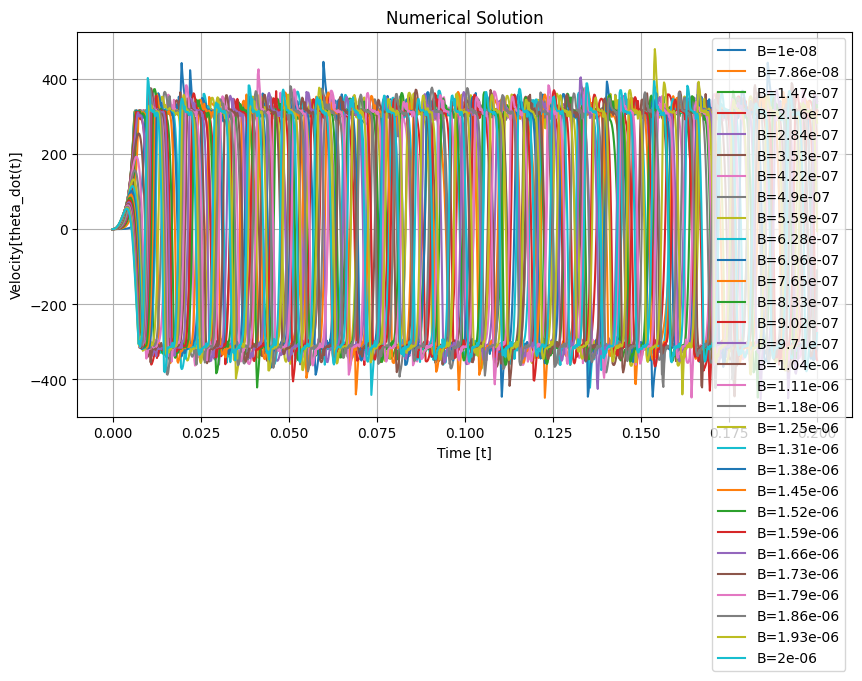

step out field 6.275862068965517e-07 Nm


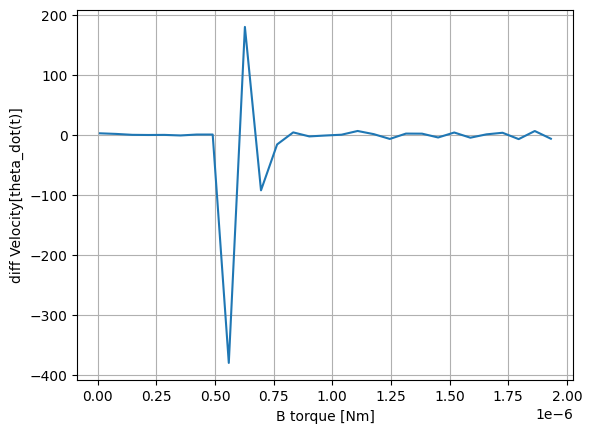

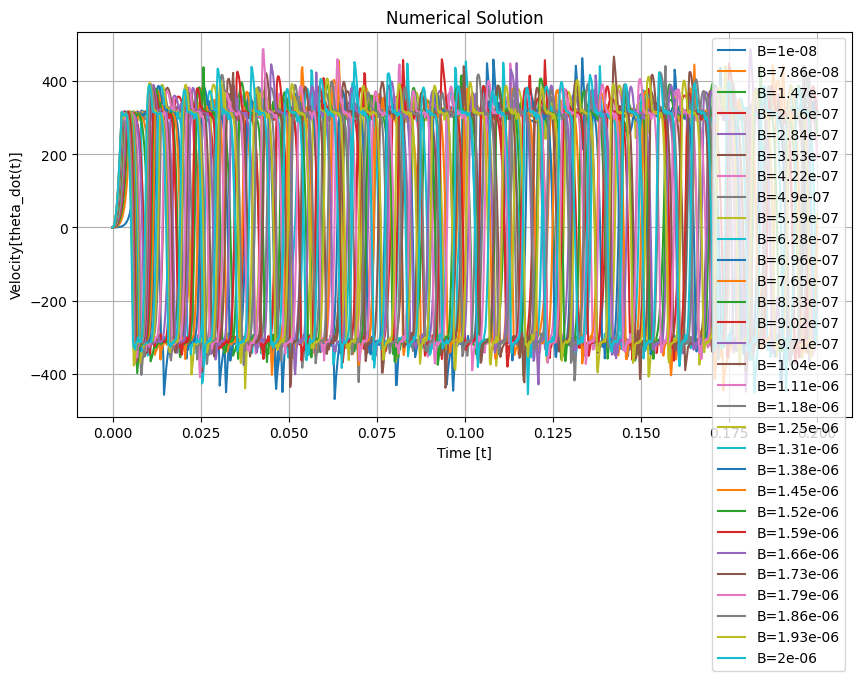

step out field 6.275862068965517e-07 Nm


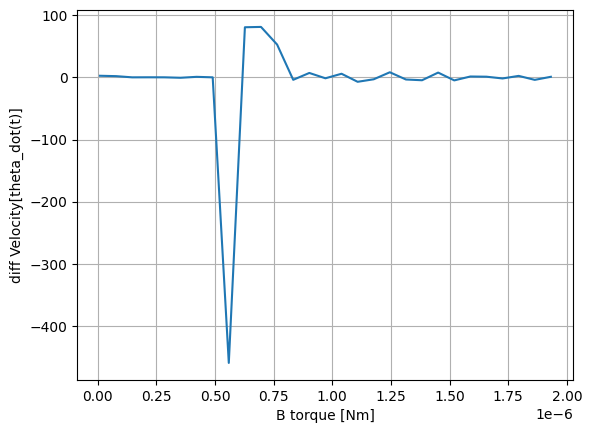

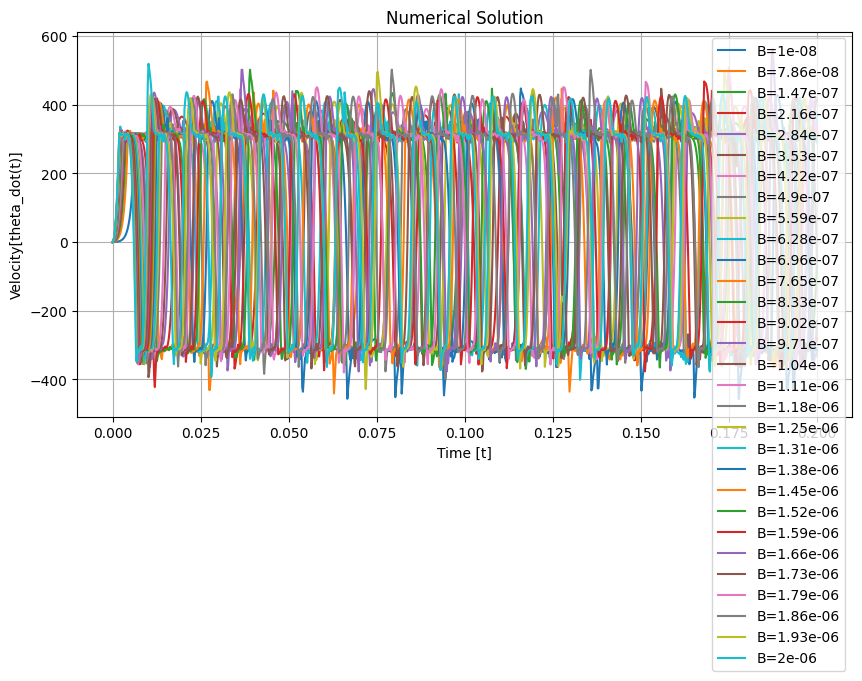

step out field 6.962068965517241e-07 Nm


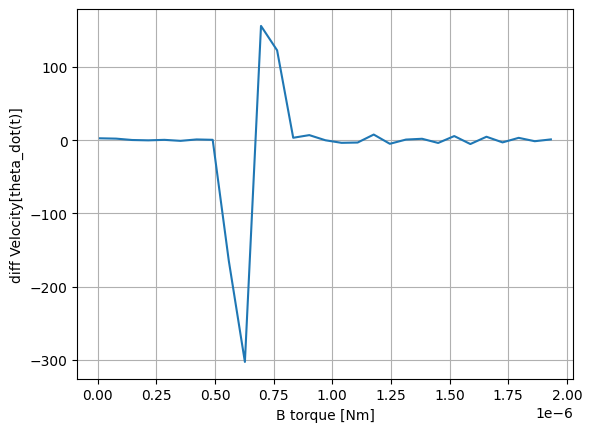

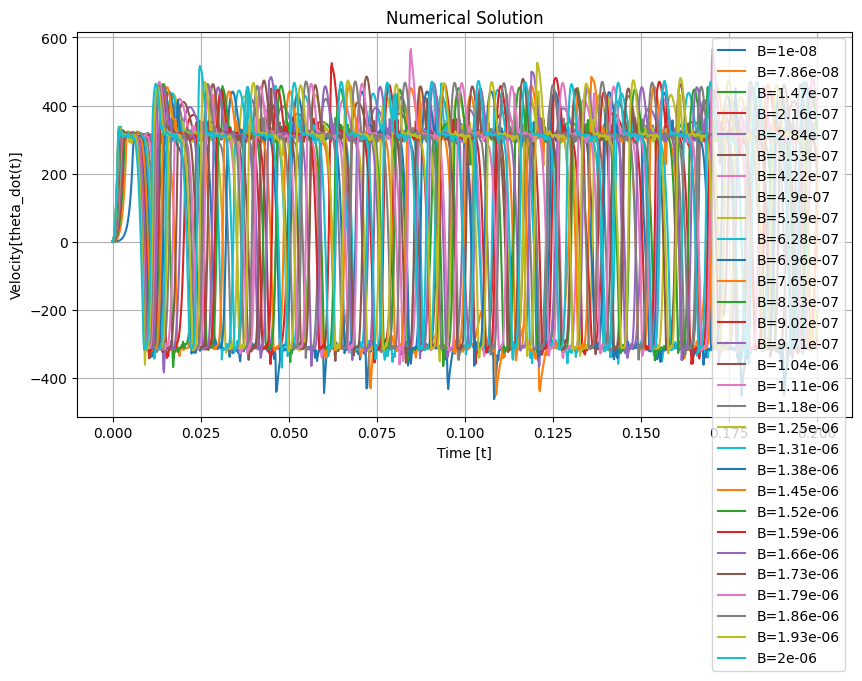

step out field 6.275862068965517e-07 Nm


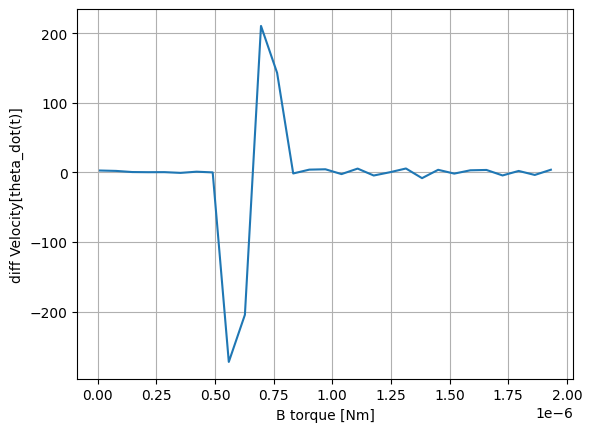

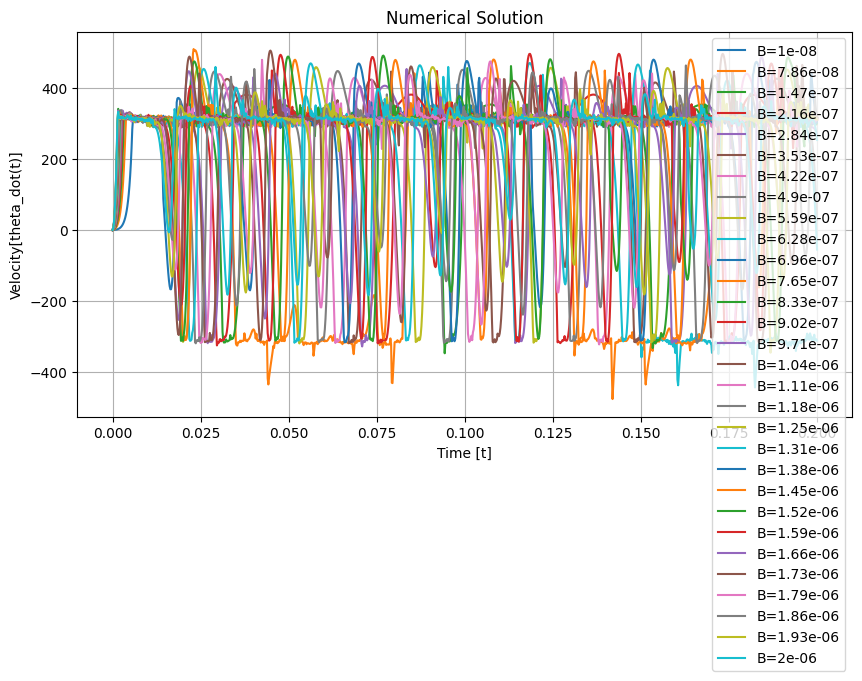

step out field 7.648275862068966e-07 Nm


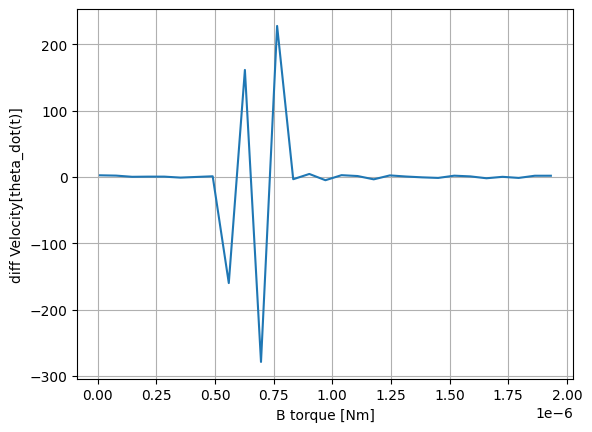

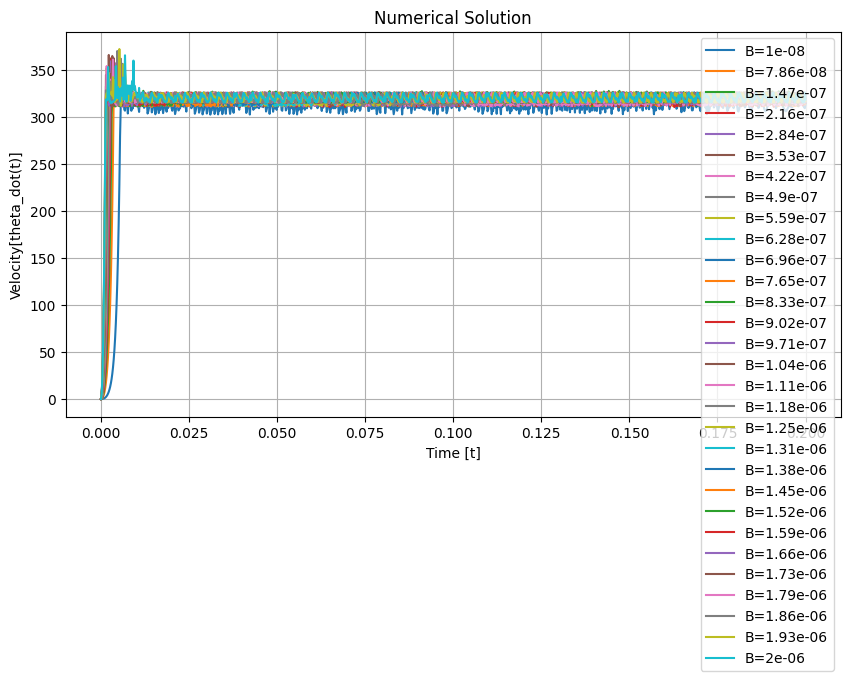

step out field 1.4724137931034484e-07 Nm


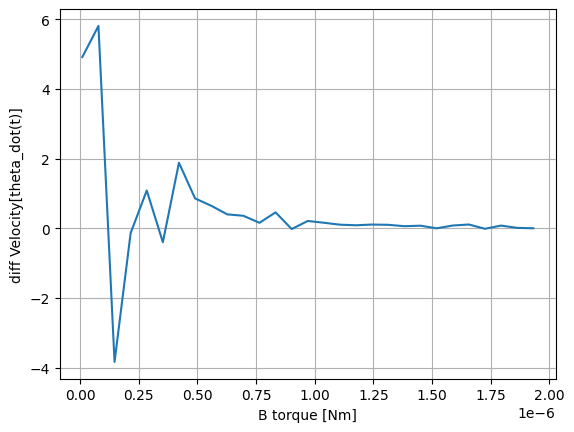

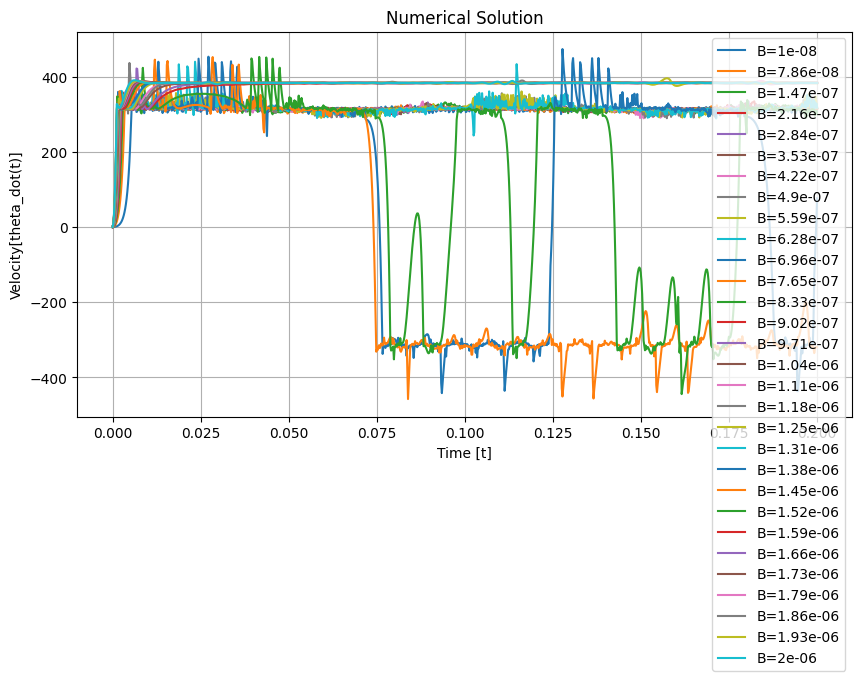

step out field 9.020689655172413e-07 Nm


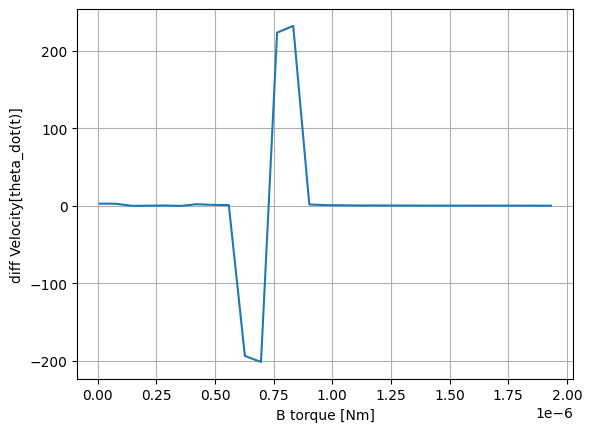

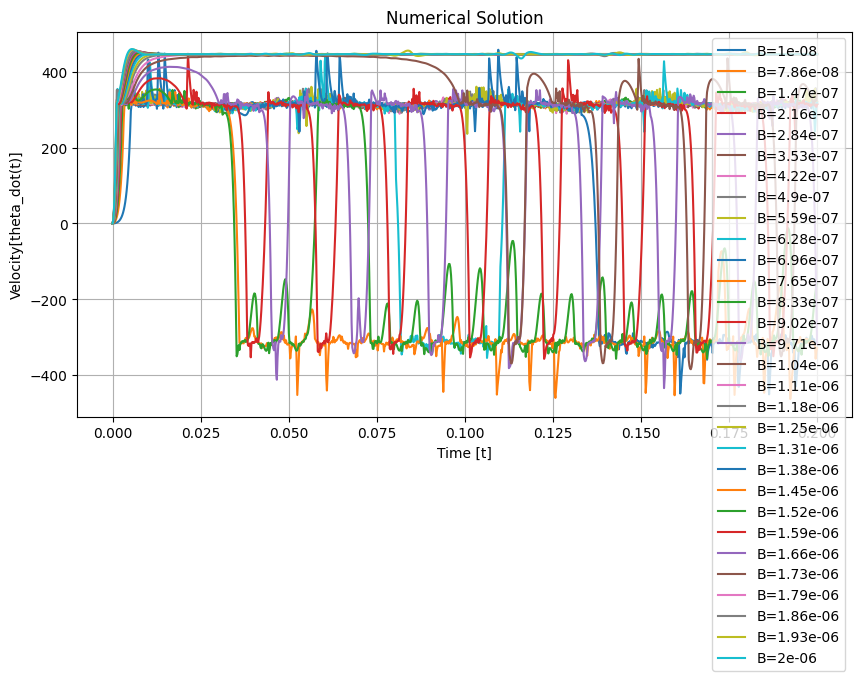

step out field 7.648275862068966e-07 Nm


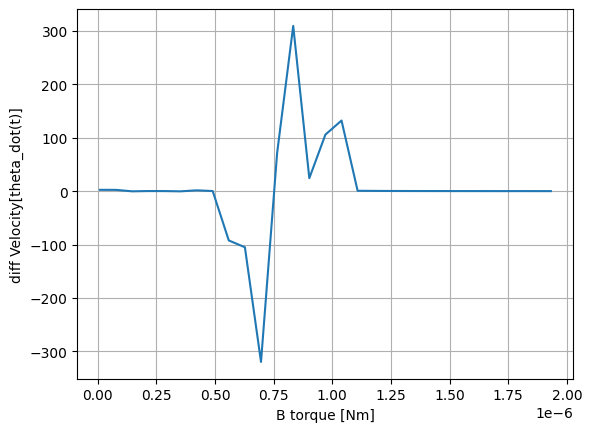

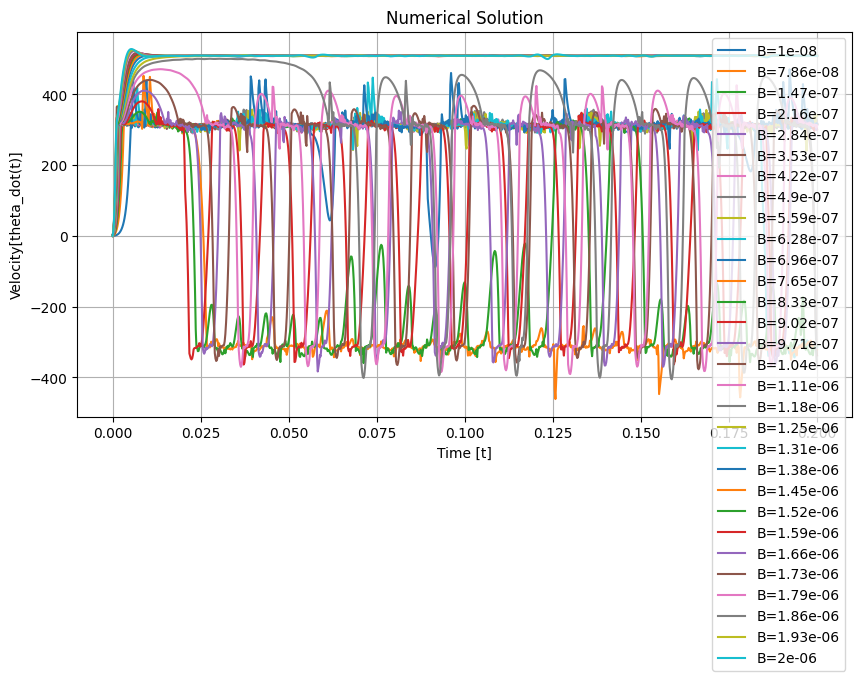

step out field 7.648275862068966e-07 Nm


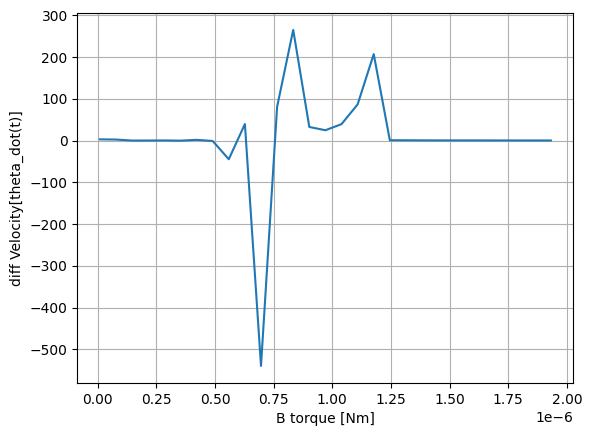

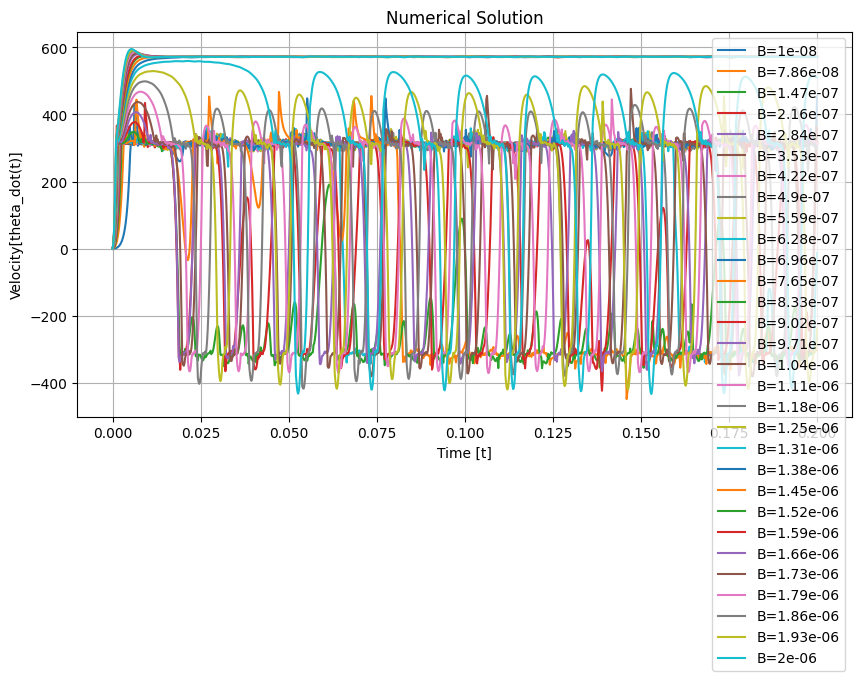

step out field 7.648275862068966e-07 Nm


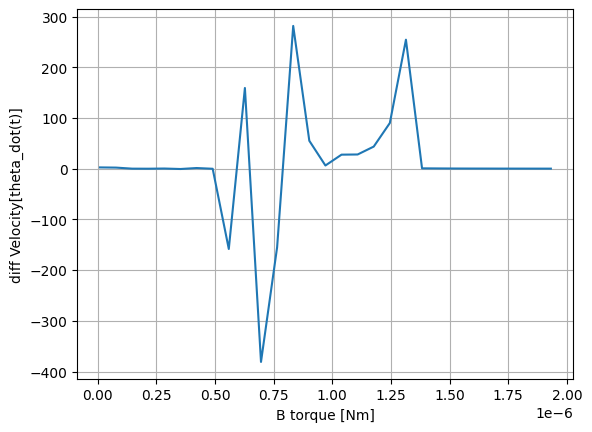

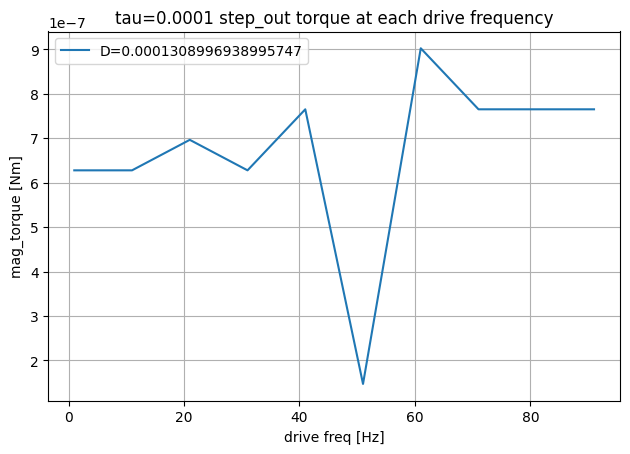

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from functools import partial

# Define the system of first-order differential equations
# y is a vector [x, v], where y[0] = x and y[1] = v = x_dot
# t is the time

m = 1.4e-5
# d = 2e-3
d = 1e-3
# J = 1/6 * m * d**2
J = 1/12 * m * (2 * d**2)
# B = 0.5e-6
B = 1e-6
C = 3.22e-9 * 0.73
C2 = C
# wb = 50*2*np.pi
# wb = 90*2*np.pi

tau = 1e-4
r = 0.75e-3
delta_trq = abs((C2*80*2*np.pi - 1.2e-6)/r) * 40 * 0
deg = 10
D = r * deg / 180 * np.pi
fb = delta_trq /10000 * 0 
# delta_trq = 0

def wrap(theta_diff):
    return theta_diff - 2*np.pi * np.floor((theta_diff+np.pi)/np.pi/2)

vels = []
mag_mult = np.linspace(0.01,2,30)
v_means = []
step_outs = []
wbs=[]

print(f"tau={tau}, D={D}")
omega_crit = 50 * 2 * np.pi

for j in range(1,90+10,10):
    wb = 2*np.pi * j
    print(j, end="\r")
    v_means = []
    vels = []
    for i in mag_mult:
        def model(t, y, B, wb, C, J):
            theta1, theta2 = y
            theta1d = theta2

            c = C if abs(theta2) >= omega_crit else -C
            theta2d = (B*np.sin(wrap(wb*t - theta1)) - c * theta2)/J
            return [theta1d, theta2d]

        # Set the initial conditions
        theta1_0 = 0.0  # Initial position: x(0)
        theta2_0 = 0.0  # Initial velocity: x_dot(0)
        initial_conditions = [theta1_0, theta2_0]

        # Set the time interval to solve for
        t_span = [0, 0.2] # from t=0 to t=20
        t_eval = np.linspace(t_span[0], t_span[1], 1000) # points where solution is saved

        # Use the numerical solver
        # 'solve_ivp' stands for "solve initial value problem"
        solution = solve_ivp(
            fun=partial(model, B=B*i, wb=wb, C=C, J=J),
            t_span=t_span,
            y0=initial_conditions,
            t_eval=t_eval
        )

        # Extract the results
        t = solution.t
        x = solution.y[0]
        v = solution.y[1]
        v_mean = np.mean(v)
        v_means.append(v_mean)
        vels.append(v)

    b_fields = B*mag_mult

    # Plot the solution
    plt.figure(figsize=(10, 5))
    for idx, vl in enumerate(vels): plt.plot(t, vl, label=f"B={b_fields[idx]:.3g}")
    plt.title('Numerical Solution')
    plt.xlabel('Time [t]')
    plt.ylabel('Velocity[theta_dot(t)]')
    plt.grid(True)
    plt.legend()
    plt.show()

    # plt.figure()
    # plt.plot(b_fields, v_means)
    # plt.ylabel('Velocity[theta_dot(t)]')
    # plt.xlabel('B torque [Nm]')
    # plt.grid()

    step_out = b_fields[np.argmax(abs(np.diff(v_means)))+1]
    step_outs.append(step_out)
    wbs.append(wb)

    plt.figure()
    plt.plot(b_fields[:-1], np.diff(v_means))
    plt.ylabel('diff Velocity[theta_dot(t)]')
    plt.xlabel('B torque [Nm]')
    plt.grid()
    print(f"step out field {step_out} Nm")

fig,ax = plt.subplots(1,1)
ax.plot(np.array(wbs)/2/np.pi, step_outs, label=f"D={D}")
ax.set_xlabel("drive freq [Hz]")
ax.set_ylabel("mag_torque [Nm]")
ax.set_title(f"tau={tau:3g} step_out torque at each drive frequency")
ax.grid()
plt.tight_layout()
plt.legend()
plt.show()